<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/09_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (1 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
getwd()

[1] "C:/Users/luzsa/OneDrive/Documents/GitHub/Andrino_DSPN_S26/ExerciseSubmissions"

In [3]:
lex_incorrect <- read_csv("LexicalData_withIncorrect.csv")

New names:
• `` -> `...1`
Rows: 74869 Columns: 9
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): D_Word
dbl (6): ...1, Sub_ID, Trial, Type, D_Zscore, Correct
num (1): D_RT
lgl (1): Outlier

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
items <- read_csv("Items.csv")

Rows: 30959 Columns: 5
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Word
dbl (3): Occurrences, Length, Log_Freq_HAL
num (1): Freq_HAL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [21]:
names(items)

[1] "Occurrences"  "Word"         "Length"       "Freq_HAL"     "Log_Freq_HAL"

In [25]:
head(lex_incorrect)
head(items)

...1,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>
1,157,1,1,710,browse,FALSE,-0.437,1
2,67,1,1,1094,refrigerant,FALSE,0.825,1
3,120,1,1,587,gaining,FALSE,-0.645,1
4,21,1,1,984,cheerless,FALSE,0.025,1
5,236,1,1,577,pattered,FALSE,-0.763,1
6,236,2,1,715,conjures,FALSE,-0.364,1


Occurrences,Word,Length,Freq_HAL,Log_Freq_HAL
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,synergistic,11,284,5.649
1,synonymous,10,951,6.858
1,syntactical,11,114,4.736
1,synthesis,9,6742,8.816
1,synthesized,11,2709,7.904
1,synthesizer,11,1390,7.237


In [28]:
names(lex_incorrect)

[1] "...1"     "Sub_ID"   "Trial"    "Type"     "D_RT"     "D_Word"   "Outlier" 
[8] "D_Zscore" "Correct"

In [31]:
lexical_data <- lex_incorrect %>%
  left_join(items %>% select(Word, Length, Log_Freq_HAL), by = c("D_Word" = "Word")) %>%
  drop_na()

head(lexical_data)

...1,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Length,Log_Freq_HAL
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,157,1,1,710,browse,FALSE,-0.437,1,6,8.856
2,67,1,1,1094,refrigerant,FALSE,0.825,1,11,4.644
3,120,1,1,587,gaining,FALSE,-0.645,1,7,8.304
4,21,1,1,984,cheerless,FALSE,0.025,1,9,2.639
5,236,1,1,577,pattered,FALSE,-0.763,1,8,1.386
6,236,2,1,715,conjures,FALSE,-0.364,1,8,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

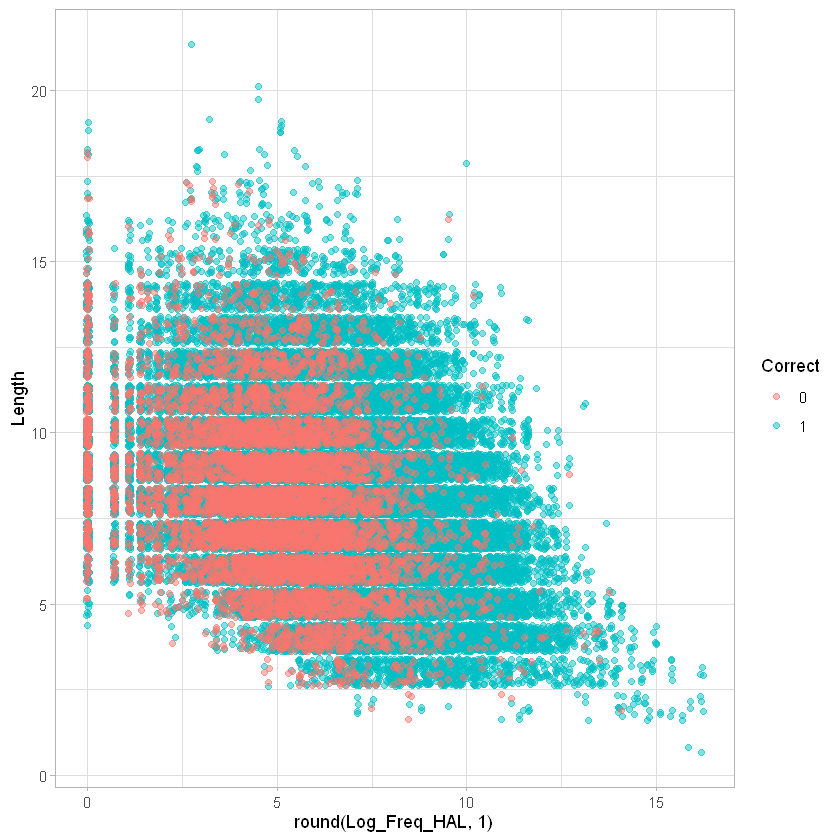

In [32]:

lexical_data$Correct <- as.factor(lexical_data$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(lexical_data,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

>I am observing an overlap between the correct and incorrect responses, with no clean separation between groups in this feature space. However, we can still see the incorrect group (light red) reaching higher for longer words with lower log frequencies.
The light red group is showing that longer words are logged more infrequently and incorrectly. The blue group is showing that shorter words are logged much more frequently and accurately. Yet, there is still a large overlap between groups, so it remains difficult to easily classify groups.

---
## 3. Logistic Regression: Fitting the model (2 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [34]:
# WRITE YOUR CODE HERE

lexical_reg <-glm(Correct ~ Length * Log_Freq_HAL, 
                 data = lexical_data, 
                 family = binomial) #correct vs. incorrect

summary(lexical_reg)


Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = binomial, 
    data = lexical_data)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> The Log_Freq_HAL coefficient of log frequency had a high coefficient meaning log frequency highly predicted correct responses and the low p-value tells me that this is a significant relationship. The Length:Log_Freq_HAL -0.01 with a negative value showed me that log frequency decreases probability of a correct response with word length increase


---
## 4. Interpreting predictions from the model (3 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [36]:
predicted_probs <- predict(lexical_reg, type = "response")
predicted_corr <- ifelse(predicted_probs > 0.5, 1, 0)


In [37]:
confusion_matrix <- table(Predicted = predicted_corr, Actual = lexical_data$Correct)
confusion_matrix

         Actual
Predicted     0     1
        0    13    44
        1  7966 62566

In [38]:
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
accuracy

[1] 0.8865262

Did the model do well at predicting lexical decision correctness? Why or why not?

>In my initial interpreation I saw that accuracy reported back a 88.7% accuracy response and offhand seems it do well in predicted correctness. Then in assessing the confusion matrix the model has a high number of 62,566 trials where it correctly predicted a correct respone.

> In assessing it further I see it overly relies on the correct and as such is reporting a high accuracy with doinga poor job at prediction, as seen where it predicted corret but the response was incorrect in missing it 7966 times. So, it is mainly just predicted 1 for each trial

## 5. QDA (3 points)

Load in the `MASS` library and fit a QDA model to the data set. The predictors are still `Length`, `Log_Freq_HAL`, and their interaction, just like the logistic regression model you just ran, and the dependent variable is still `Correct`.

*Hint: see the Classifiers tutorial.*

In [43]:
library(MASS)

In [41]:
qda <- qda(Correct ~ Length * Log_Freq_HAL, 
                 data = lexical_data)

In [42]:
qda

Call:
qda(Correct ~ Length * Log_Freq_HAL, data = lexical_data)

Prior probabilities of groups:
        0         1 
0.1130346 0.8869654 

Group means:
    Length Log_Freq_HAL Length:Log_Freq_HAL
0 8.047124     4.932123            37.95260
1 7.979971     6.444849            49.34219

Now look at how well the predicted `Correct` values compare with actual `Correct` values for the whole data set. Output a confusion matrix and overall prediction accuracy.

In [45]:
qda_predicted <- predict(qda, lexical_data)

In [46]:
confusion_qda <- table(Predicted = qda_predicted$class, Actual = lexical_data$Correct)

In [49]:
accuracy_qda <- sum(diag(confusion_qda)) / sum(confusion_qda)

In [50]:
confusion_qda
accuracy_qda

         Actual
Predicted     0     1
        0   455  1647
        1  7524 60963

[1] 0.8700789

How does QDA prediction performance differ from that of logistic regression?

> For accuracy the model actually performs marginally worse at 87% yet, it is actually appropriately detecting errors in predictions; when the model predicted incorrect and it was actually in correct, this number rose from 13 to 455. So while the logsitic regression had a higher accuracy percentage the QDA was predicting better and was the more useful model

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
>n/a